# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [ ]:
# Mounts Google drive in Google Colab making it possible to load in the dataset from your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/Data Science and Machine Learning MIT/Course 2: Making Sense of Unstructured Data/Project 1: Making Sense of Unstructured Data/Customer_Personality_Segmentation.csv", sep="\t")

In [ ]:
# We use this to get an idea about how big the dataset is that we are dealing with
# From this code we can see our data has 2,240 rows and 29 columns.
data.shape

(2240, 29)

In [ ]:
# Copying the data to another variable to avoid making any unwanted changes to original data
df = data.copy()

## **Data Overview**

#### **Question 1**: What are the data types of all the columns?

In [ ]:
# We can use df.dtypes to just show the data types of the columns.
# We can also use df.info() which will give us the types of the columns as well as gain more insight such as if there are any null values present.
# It can't hurt to use the code which give us more information to give us a better grasp of the dataset so in this case we will use info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

##### **Observations:**
From the above code we can clearly see the data types of all of the 29 columns in the dataset.  Marital_Status, Education, and Dt_Customer are categorical columns of type object.  These object columns probably will not be very helpful in our analysis of sales so we can consider dropping them later.  

 All the other columns are numerical columns of type int besides Income which is a numerical column of type float.  In addition to this, we can see that all columns have no null values besides Income which contains 24 null values.  We will have to deal with those before getting too deep into our analysis of the data.

 We might want to convert the Year_Birth column into an Age column and the Dt_Customer into a Years_of_Loyalty column before dropping because Age and Years_of_Loyalty could be helpful factors in our later analysis.

In [ ]:
# Let's use the Year_Birth column to append an Age column to our dataframe to get better insights from that data column\
#First import date from datetime
from datetime import date
# Gets the current year from the date and subtracts a person's birth year to calculate their age and append the column to the copy we made of our data
df['Age'] = date.today().year - df['Year_Birth']

In [ ]:
# Let's check to make sure the above code did exactly what we wanted it to do
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0,59
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,3,11,0,55
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,3,11,0,41
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,3,11,1,52
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0,76


By checking the first 10 rows of the data, we can see that there is an age column that calculated the age of each individual customer correctly.  We can use that column in our analysis to get much better insights than if we just used Year_Birth.  Now we should try and do a similar procedure with the Dt_Customer column.

In [ ]:
# Let's use the Dt_Customer column to extract the years a customer has been using the company and append a Years_of_Loyalty column to our dataframe to get better insights from that data column
# Converting Dt_Customer type to datetime
from datetime import datetime
df.Dt_Customer = pd.to_datetime(df.Dt_Customer,format='%d-%m-%Y')

# Gets the year from the Dt_Customer column and subtracts it from the current year and append the Years_of_Loyalty column with that value to the copy we made of our data repeating for every row
df['Years_of_Loyalty'] = date.today().year - df.Dt_Customer.dt.year

In [ ]:
# Let's check to make sure the above code did exactly what we wanted it to do
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Years_of_Loyalty
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,14
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,12
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,13
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,12
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,12
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0,59,13
6,965,1971,Graduation,Divorced,55635.0,0,1,2012-11-13,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,3,11,0,55,14
7,6177,1985,PhD,Married,33454.0,1,0,2013-05-08,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,3,11,0,41,13
8,4855,1974,PhD,Together,30351.0,1,0,2013-06-06,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,3,11,1,52,13
9,5899,1950,PhD,Together,5648.0,1,1,2014-03-13,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0,76,12


By checking the first 10 rows of the data, we can see that there is a Years_of_Loyalty column that took the amount of years each individual customer has been using the provider's services correctly. We can use that column in our analysis to get much better insights than if we just used Dt_Customer. Now we can continue with our analysis.

#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [ ]:
# To check the statistical summary we use df.describe()
# We can add the .T to the end to take the trasform and make the table more easily readable.
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,2240.0,5592.159821,0.0,2828.25,5458.5,8427.75,11191.0,3246.662198
Year_Birth,2240.0,1968.805804,1893.0,1959.0,1970.0,1977.0,1996.0,11.984069
Income,2216.0,52247.251354,1730.0,35303.0,51381.5,68522.0,666666.0,25173.076661
Kidhome,2240.0,0.444196,0.0,0.0,0.0,1.0,2.0,0.538398
Teenhome,2240.0,0.50625,0.0,0.0,0.0,1.0,2.0,0.544538
Dt_Customer,2240,2013-07-10 10:01:42.857142784,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 12:00:00,2013-12-30 06:00:00,2014-06-29 00:00:00,NaN
Recency,2240.0,49.109375,0.0,24.0,49.0,74.0,99.0,28.962453
MntWines,2240.0,303.935714,0.0,23.75,173.5,504.25,1493.0,336.597393
MntFruits,2240.0,26.302232,0.0,1.0,8.0,33.0,199.0,39.773434
MntMeatProducts,2240.0,166.95,0.0,16.0,67.0,232.0,1725.0,225.715373


##### **Observations:**


*   The average yearly household income is about 52,247.25 dollars and has a large standard deviation of about 25,173.08 dollars

*   The income also has a high range with a minimum value of 1730 dollars and a maximum value of 666,666 dollars.

*   On average, a customer makes 4 web purchases, 3 catalog purchases, 6 in-store purchases, and has about 5 web visits per month.

*   The significant gap between the upper quartile and maximum values for variables such as Income, MntWines, and MntMeatProducts could indicate upper outliers.

*   Variables such as Complain, AcceptedCmp1, AcceptedCmp2, AcceptedCmp3, AcceptedCmp4, AcceptedCmp5, and Response should only take values of 0 or 1 which looks to be correct based on the statistics in the table.

*   The variables Z_CostContact and Z_Revenue have means of 3 and 11 respectively and standard deviations of 0 and 0.  Based on this, it seems that the value of Z_CostContact is 3 for every row in the dataset and the value of Z_Revenue is 11 for each row in the dataset.  Therefore, these columns probably won't be important when doing the latter parts of our analysis so we could think about dropping them.









#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [ ]:
# When using the .info() above we were able to get a sneak peek into the answer to this question.
# When just looking for if there are any null values we can use df.isnull.sum()
# This will give a table showing the sum of null values in each column
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


<Axes: xlabel='Income'>

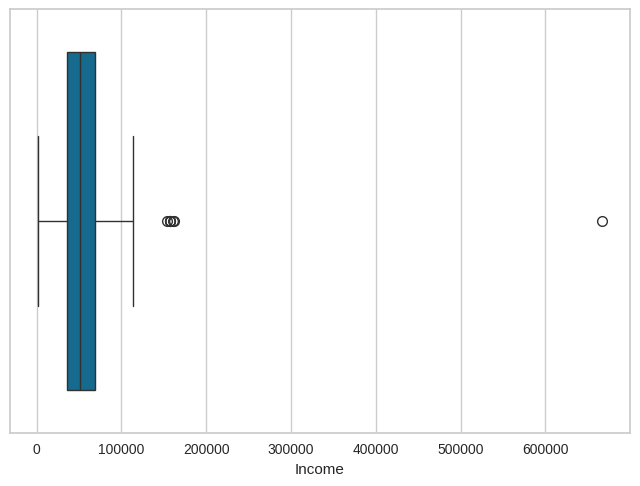

In [ ]:
sns.boxplot(data = df,x="Income")

In [ ]:
# Checking the missing values further to see what the missing values are listed as (0,Nan,Unknown,etc.)
df.Income.value_counts(dropna = False)

,count
Income,
NaN,24
7500.0,12
35860.0,4
18929.0,3
37760.0,3
...,...
33562.0,1
57731.0,1
73807.0,1


In [ ]:
# Imputing NaN with the median of the income column
df['Income'].fillna(df["Income"].median(), inplace = True)

In [ ]:
# One final check to make sure we took care of all the null values
print(df.isnull().sum())
df.Income.value_counts()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
Age                    0
Years_of_Loyalty       0
dtype: int64


,count
Income,
51381.5,24
7500.0,12
35860.0,4
18929.0,3
37760.0,3
...,...
33562.0,1
57731.0,1
73807.0,1


##### **Observations:**
As we saw earlier when using the .info() function and again now using the .isnull().sum() function, we can see there are 24 null values in the dataset that all appear in the income column.

From the above boxplot of the income column we can see there are a few outliers.  Due to the possible impact from these outliers, it would be best to impute the missing values from the income column with the median value rather than the mean.

From the third block of code we see that the missing values are listed as Nan so now we know we can write code to replace the Nan values in the income column with the median of that column in the fourth block of code and do one final check to make sure that all missing values have been filled in.

From the fourth block we see that using df.isnull().sum() gives us a table which states that there are now zero null values.  By using df.Income.value_counts() we see that there are 24 entries with the income value of 51381.5. This confirms that the 24 missing values were imputed with the median value correctly and we can now continue on with our analysis.

#### **Question 4**: Are there any duplicates in the data?

In [ ]:
# This code gives the sum of the duplicated entries in the dataset
df.duplicated().sum()

np.int64(0)

##### **Observations:**
By using the above code we can see that our data does not contain any duplicate entries.

## **Exploratory Data Analysis**

Before starting our Univariate and Bivariate analysis, we should drop the columns that won't have much impact on our analysis.

In [ ]:
# Drops the columns that won't have much impact on creating new business strategies to target specific groups
df.drop(columns = ['ID', 'Year_Birth','Education','Marital_Status','Dt_Customer','AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Z_CostContact','Z_Revenue'], inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Income               2240 non-null   float64
 1   Kidhome              2240 non-null   int64  
 2   Teenhome             2240 non-null   int64  
 3   Recency              2240 non-null   int64  
 4   MntWines             2240 non-null   int64  
 5   MntFruits            2240 non-null   int64  
 6   MntMeatProducts      2240 non-null   int64  
 7   MntFishProducts      2240 non-null   int64  
 8   MntSweetProducts     2240 non-null   int64  
 9   MntGoldProds         2240 non-null   int64  
 10  NumDealsPurchases    2240 non-null   int64  
 11  NumWebPurchases      2240 non-null   int64  
 12  NumCatalogPurchases  2240 non-null   int64  
 13  NumStorePurchases    2240 non-null   int64  
 14  NumWebVisitsMonth    2240 non-null   int64  
 15  Complain             2240 non-null   i

ID is just an Identification number that is unique to each customer.  This won't provide any insight for us so we can drop it.

We can go ahead and drop Year_Birth because we already used that info and appended a better column of Age so we no longer need Year_Birth.

Education and Marital_Status are categorical variables.  If we wanted to include these we would have to correlate each given response to a number instead of a word.  Therefore, we could could use these columns but because we already have so many features and would be getting a similar insights from columns such as Income, Kidhome, Teenhome, etc., we should be fine dropping Education and Marital_Status.

Dt_Customer we can drop because we already extracted the important information from that column that could be valuable and stored it in the Years_of_Loyalty.

AcceptedCmp1, AcceptedCmp2, AcceptedCmp3, AcceptedCmp4, AcceptedCmp5 are variables to save whether or not a customer responded to the first, second, third, fourth, and fifth campaigns respectively.  Those are not important to us when trying to look at insghts regarding sales numbers because they are rather old and can be dropped accordingly.  Instead we will just keep the Response variable which is takes the same information but for the most recent campaign.

As mentioned earlier, Z_CostContact and Z_Revenue have values of 3 for every row in the dataset and 11 for each row in the dataset respectively.  Since the values are all the same this won't help in our analysis and we can drop both of these columns.

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

Income
Skew : 6.8


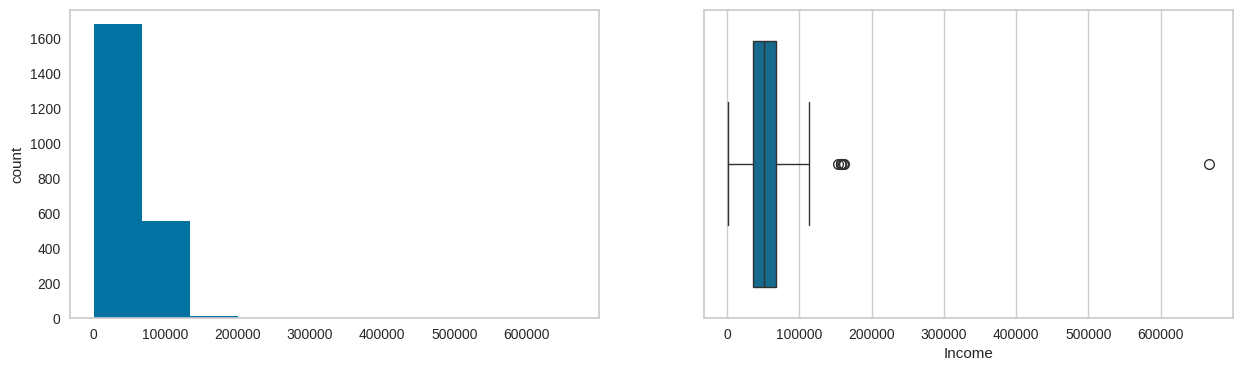

Kidhome
Skew : 0.64


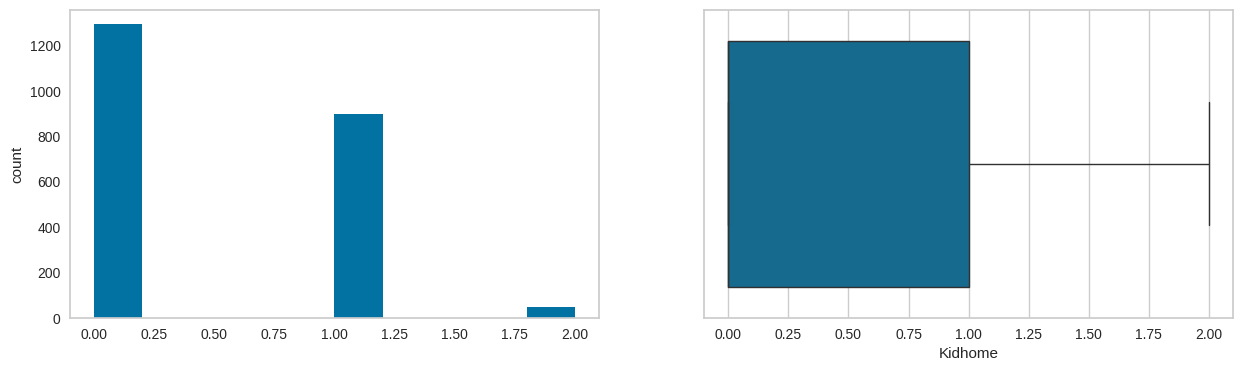

Teenhome
Skew : 0.41


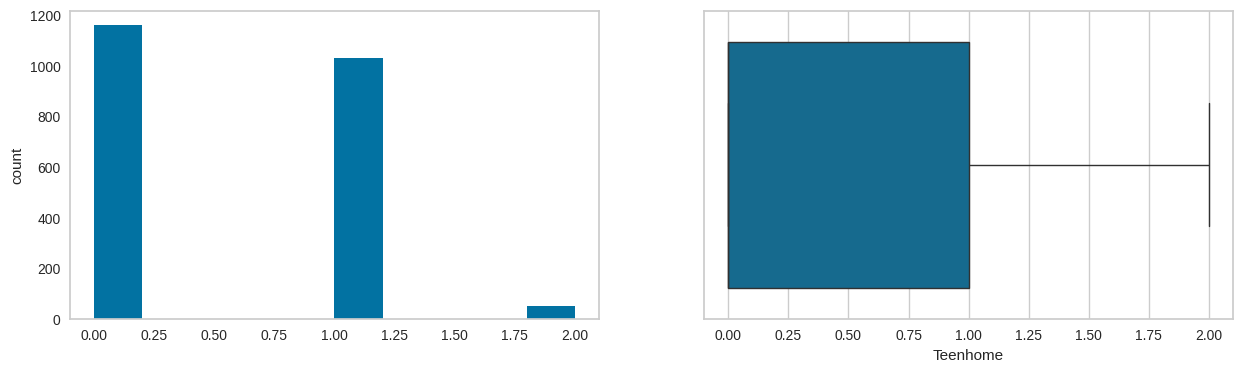

Recency
Skew : -0.0


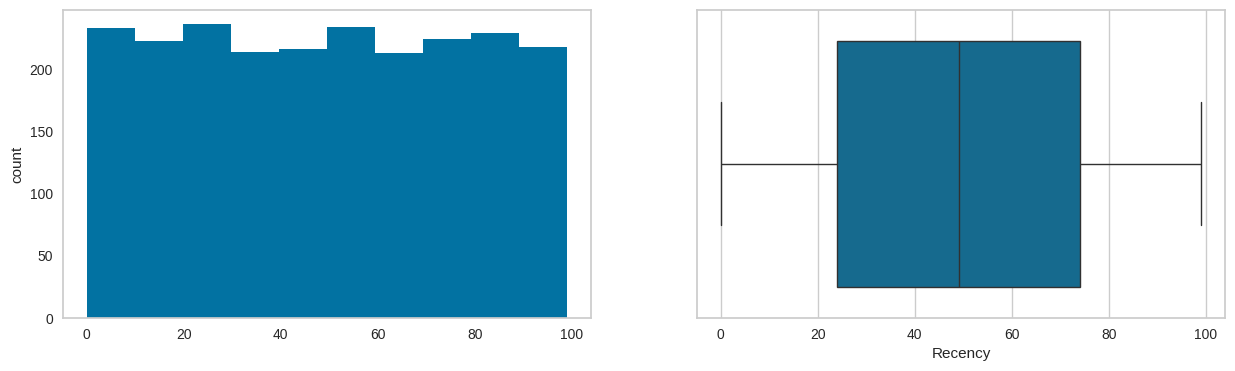

MntWines
Skew : 1.18


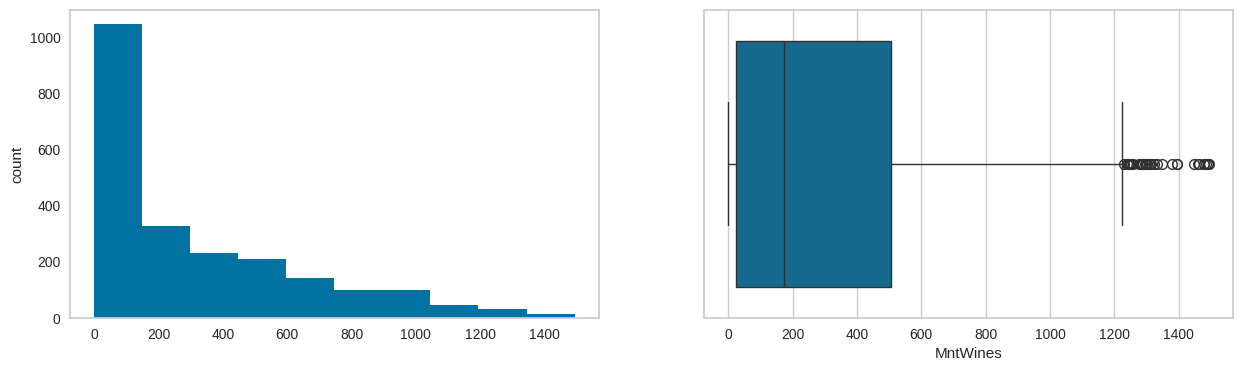

MntFruits
Skew : 2.1


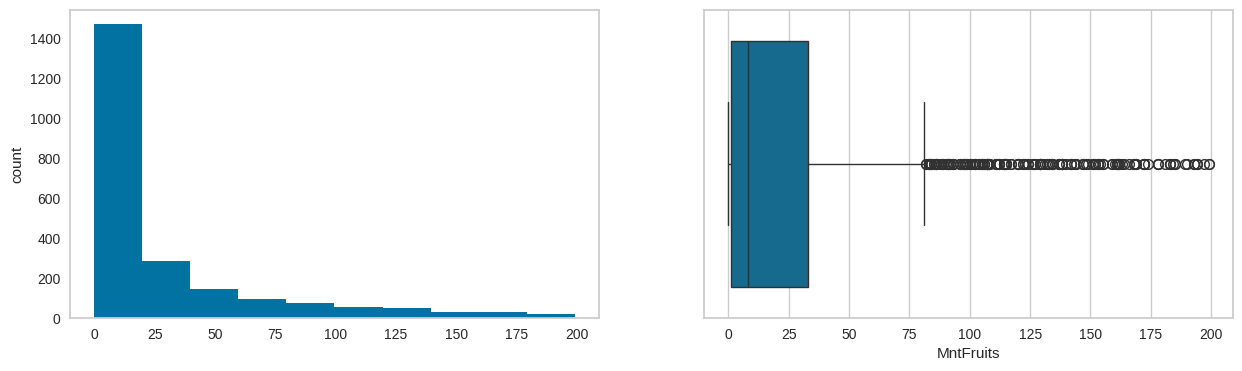

MntMeatProducts
Skew : 2.08


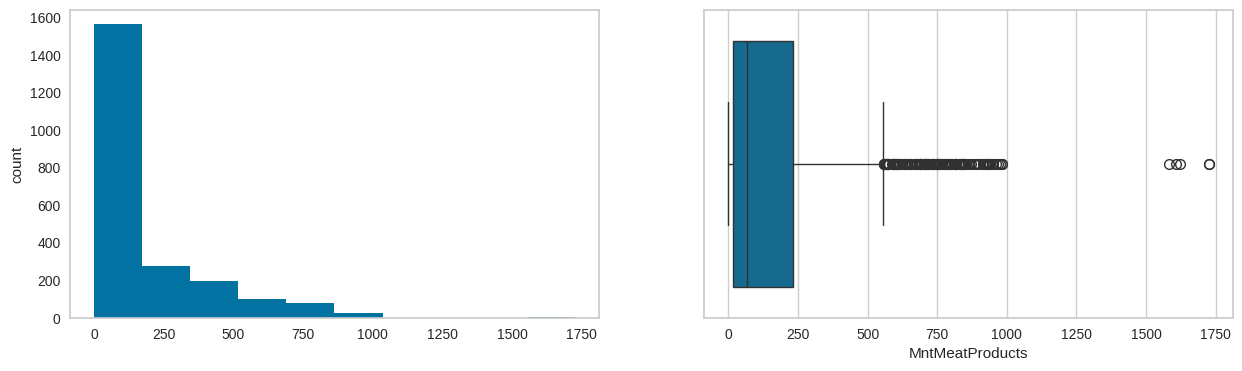

MntFishProducts
Skew : 1.92


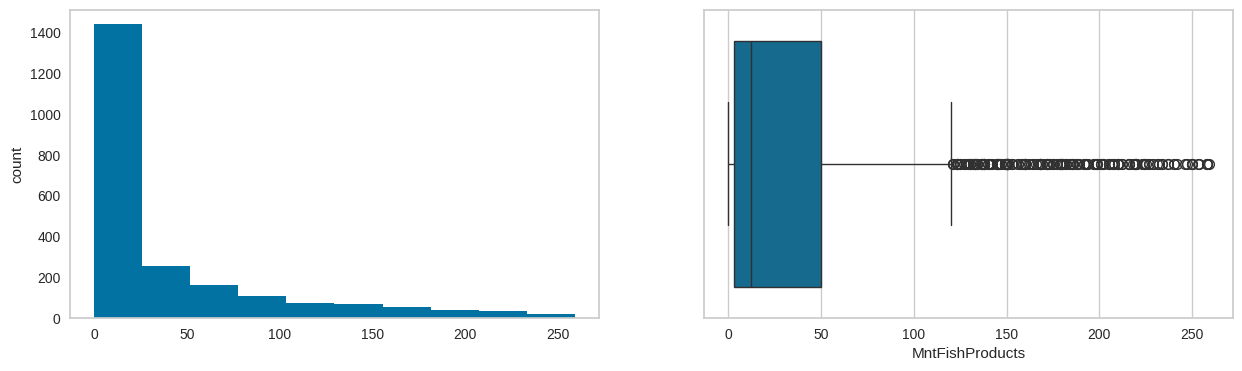

MntSweetProducts
Skew : 2.14


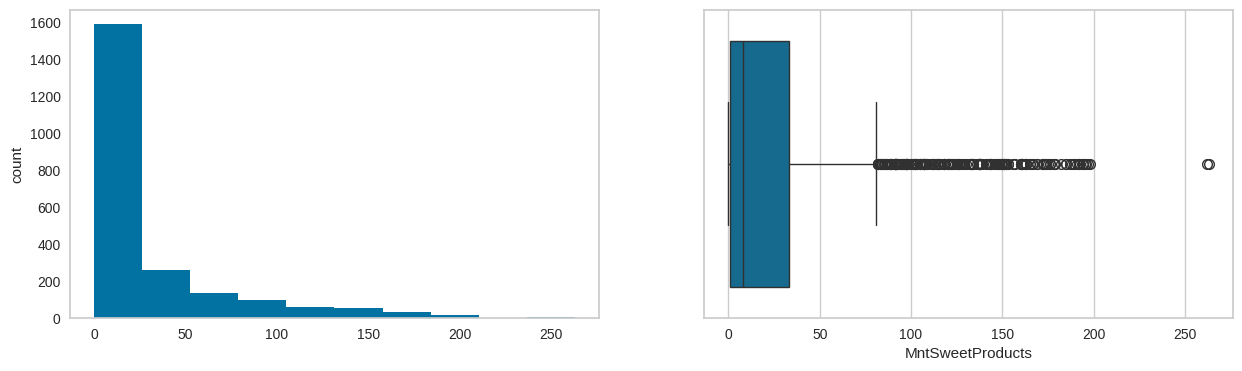

MntGoldProds
Skew : 1.89


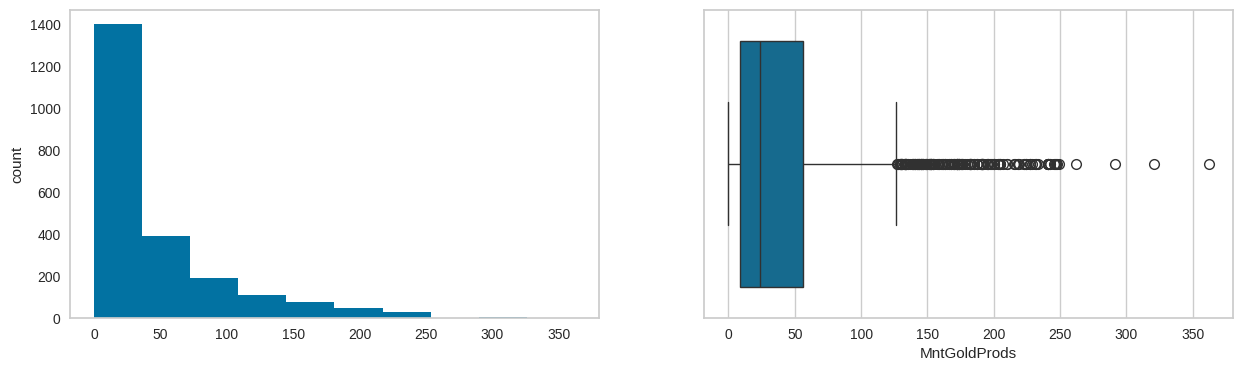

NumDealsPurchases
Skew : 2.42


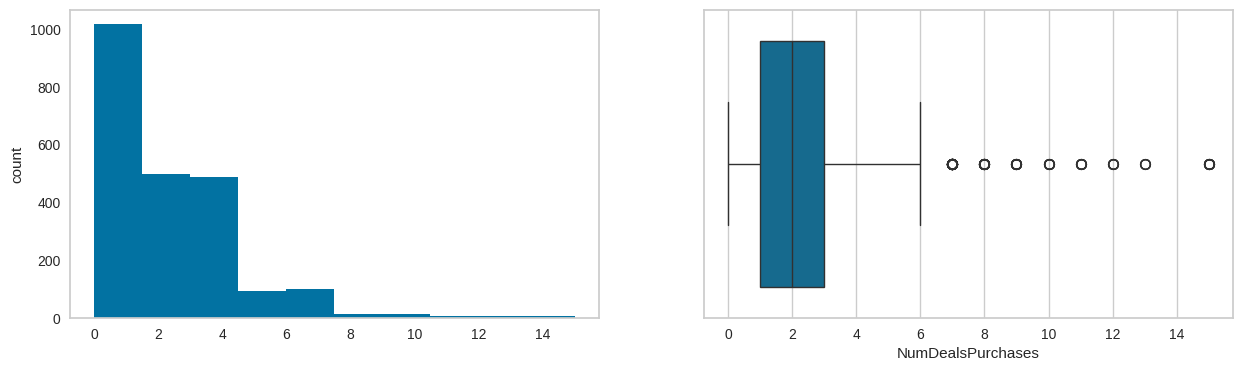

NumWebPurchases
Skew : 1.38


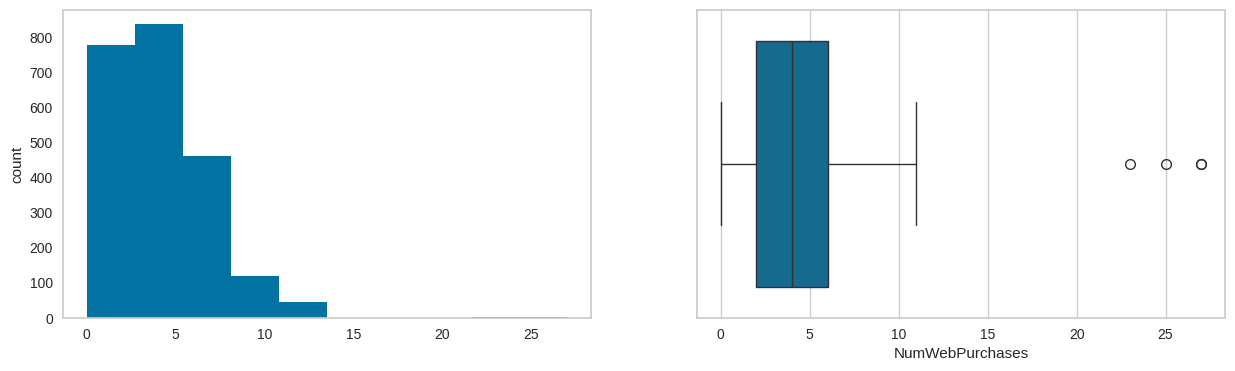

NumCatalogPurchases
Skew : 1.88


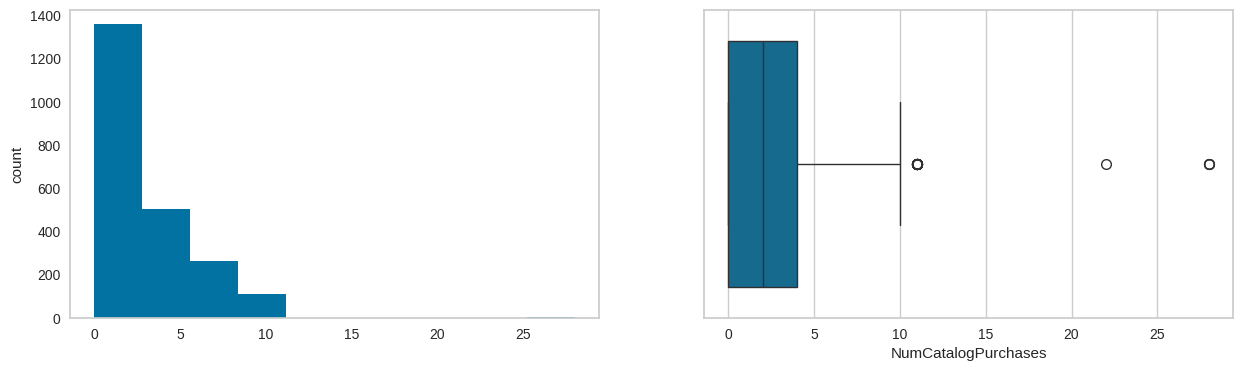

NumStorePurchases
Skew : 0.7


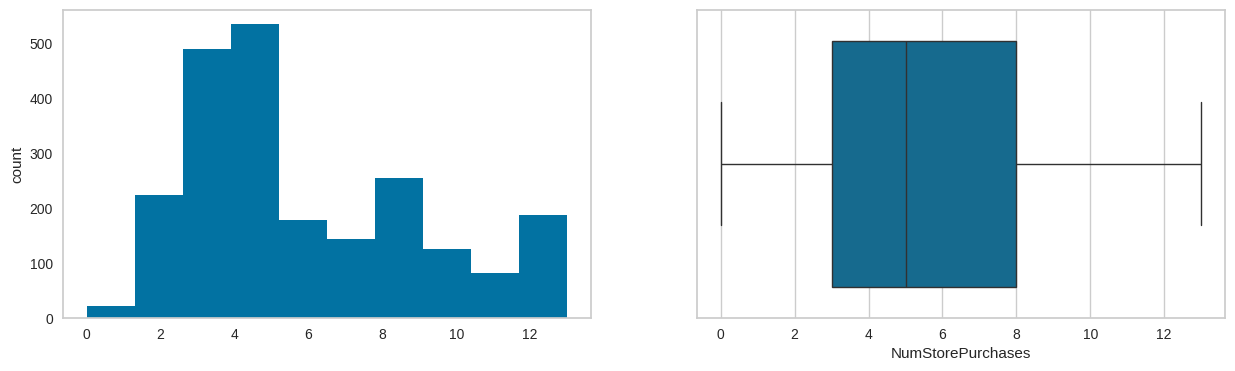

NumWebVisitsMonth
Skew : 0.21


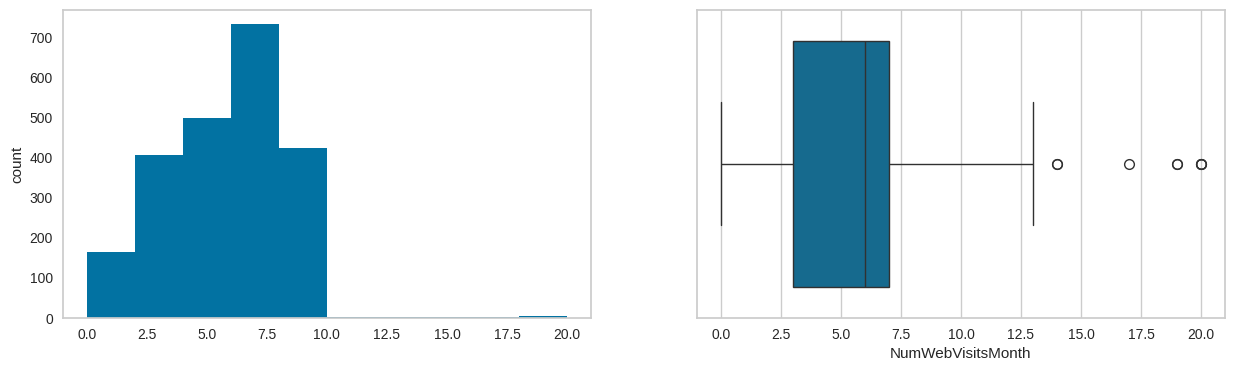

Complain
Skew : 10.19


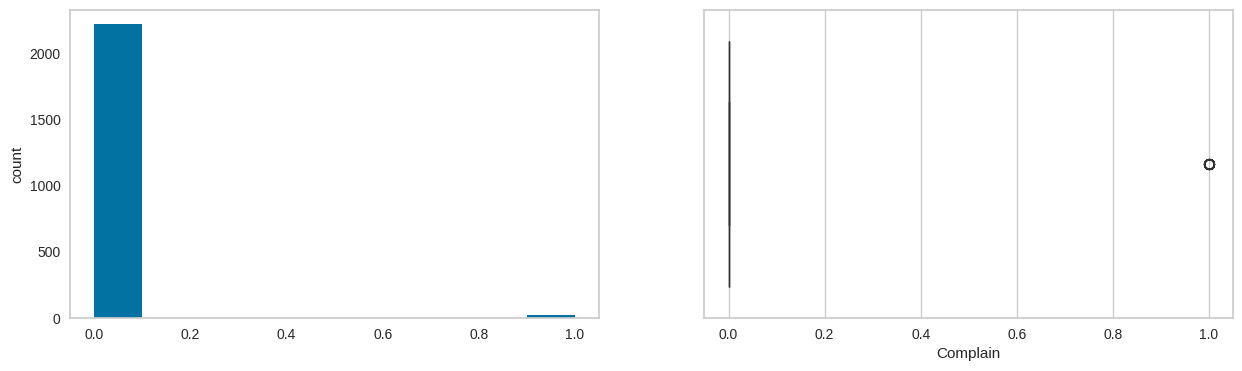

Response
Skew : 1.97


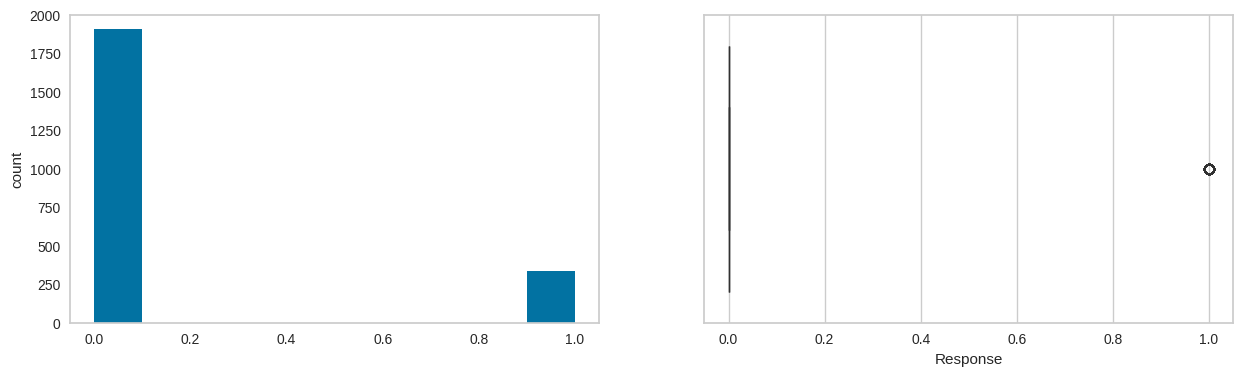

Age
Skew : 0.35


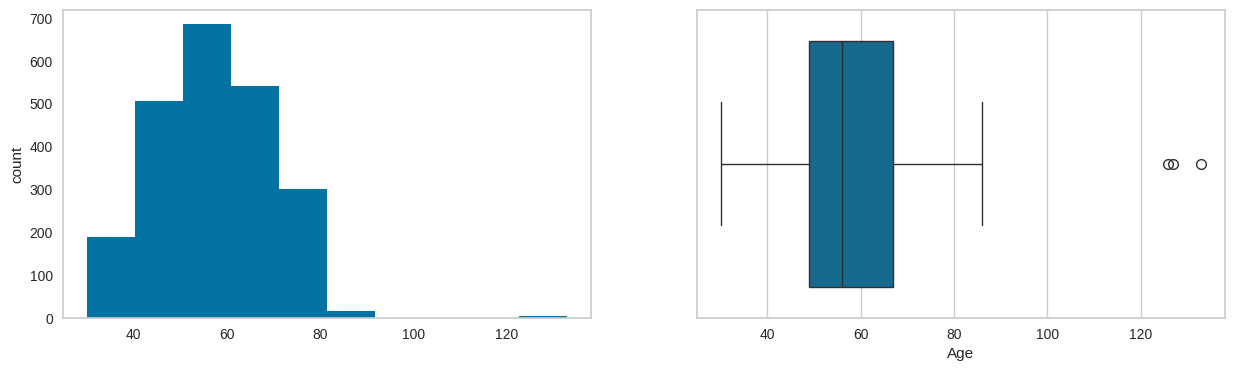

Years_of_Loyalty
Skew : 0.04


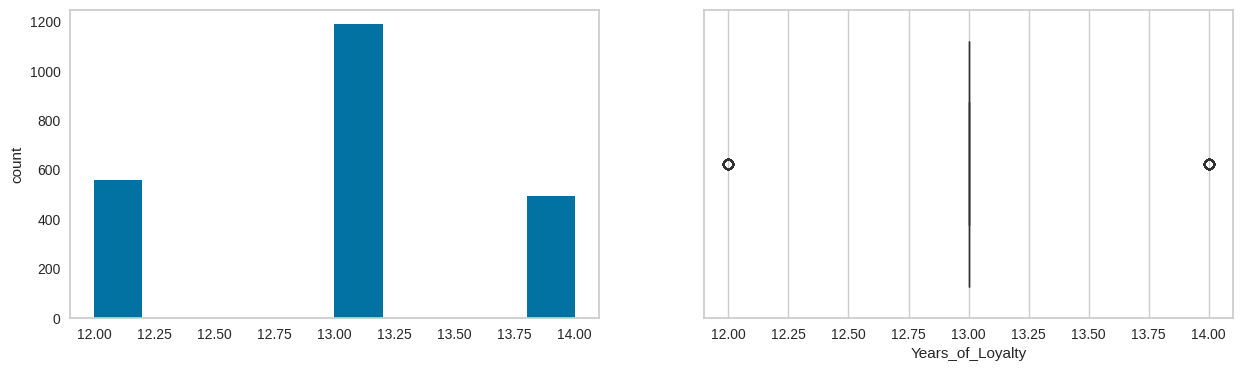

In [ ]:
# This code will give us a histogram as well as a boxplot for each of the columns in our dataset
# From here we can do our univariate analysis and see the distributions, skews, trends, outliers, etc. for our data
for col in df.columns:
    print(col)
    print('Skew :',round(df[col].skew(),2))
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    df[col].hist(bins=10, grid=False)
    plt.ylabel('count')
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.show()

##### **Observations:**

###### **Income-**
Income is continuous and heavily right skewed with a majority of values between 0 and 100,000 dollars.  This variable also has a couple of outliers.

###### **Kidhome and Teenhome-**
Kidhome and Teenhome are not continuous and have most values of both variables being 0.  From the boxplots we can see that neither of these variables have any outliers.

###### **Recency-**
Recency is close to a uniform distribution but not continuous as number of day only takes integer values.  Values are pretty evenly spread out between 0 and 100 days.  There are no outliers as shown by the boxplot.

###### **Spending Variables (MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds)-**
MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts and MntGoldProds are all continuous, right skewed, and have outliers.

###### **NumDealsPurchases, NumWebPurchases, NumCatalogPurchases-**
NumDealsPurchases, NumWebPurchases and NumCatalogPurchases are right skewed, have some outliers and are not continuous as number of purchases only takes integer values.

###### **NumStorePurchases-**
NumStorePurchases is slightly right skewed, has no outliers, has a maximum count at about 4 purchases, and is not continuous.

###### **NumWebVisitsMonth-**
NumWebVisitsMonth has a maximum count at around 6 or 7, has a few outliers and is not continuous.

###### **Complain and Response-**
Complain and Response are variables that can only take values of 0 and 1 so as zero has the maximum count in both cases, one can be considered an outlier based on the boxplot.

###### **Age-**
Age has a maximum count at around 55, has a couple of outliers and is not continuous.

###### **Years_of_Loyalty-**
Years_of_Loyalty only has 3 values (12, 13, and 14) so as 13 has the maximum count, 12 and 14 can be considered outliers in opposite directions based on the boxplot.

### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

In [ ]:
# Set the plot size and plot the pairplot of all vairables to perform Bivariate analysis
sns.pairplot(df, diag_kind="kde", corner=True);
plt.show()

Output hidden; open in https://colab.research.google.com to view.

<Axes: >

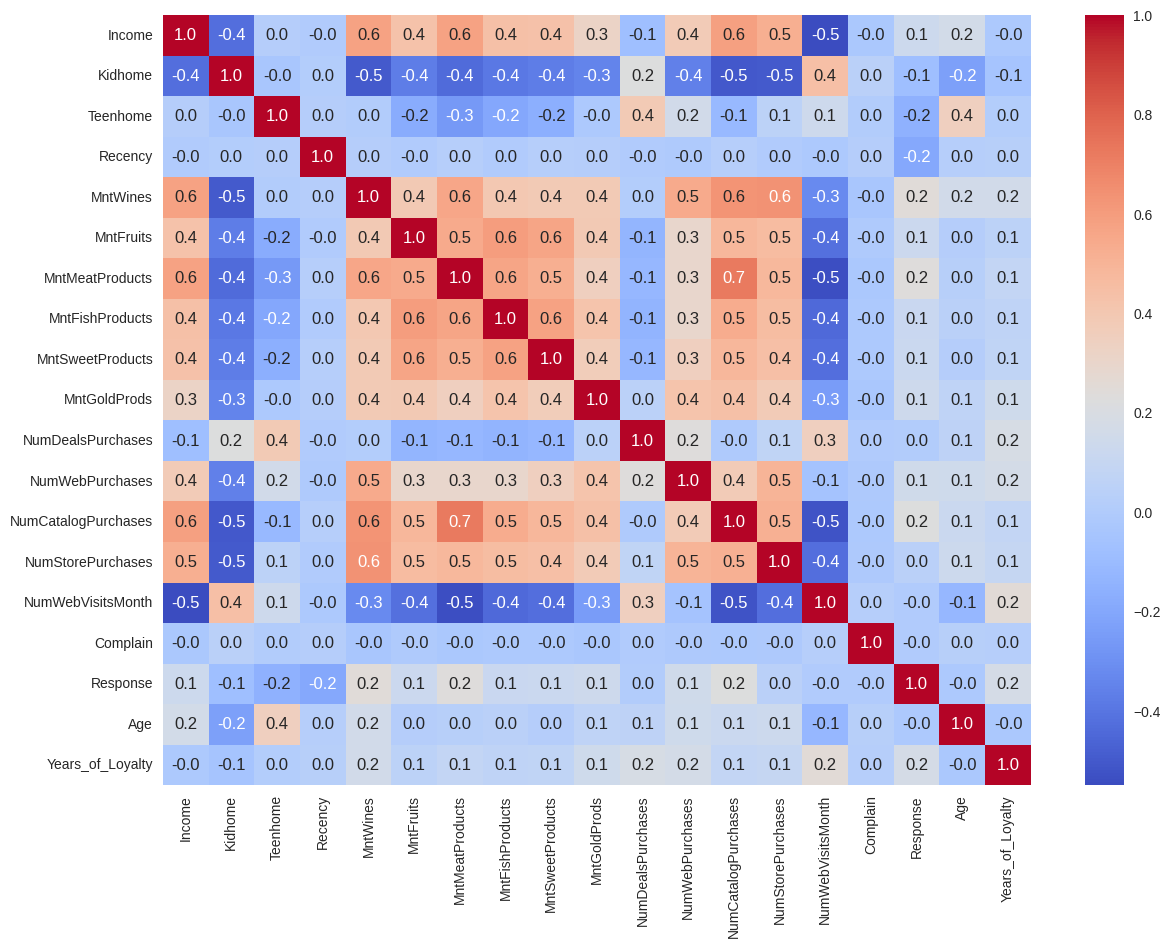

In [ ]:
# Calculate the correlation matrix of our dataset
corr = df.corr()

# Plot the heatmap with correlation values in squares, and labels to say what each row and column in the heatmap represent
plt.figure(figsize = (14, 10))
sns.heatmap(corr, annot = True, cmap = 'coolwarm',
        fmt = ".1f",
        xticklabels = corr.columns,
        yticklabels = corr.columns)

##### **Observations:**
The graphs of the kernel density estimate down the diagonal of the pair plot shows us a smooth curve of the distributions of each variable which we already went over when looking at the histograms in the univariate analysis.

The scatter plots in the pair plot are used to show how 2 variables interact with eachother.  Usually you can see some trends in the graphs that can give you some insights but with so many variables and so many data points, the graphs don't really give as much information as we would like.  In this case, the heatmap gives us a much clearer picture at what is going on in this dataset.

Looking at the heatmap we can see that variable pairs such as NumCatalogPurchases and MntMeatProducts, Income and MntWines, NumStorePurchases and MntWines, etc. are positively correlated meaning as one variable increases so does the other or as one variable deacreases so does the other.  Variable pairs such as Income and NumWebVisitsMonth, Kidhome and MntWines, Kidhome and NumStorePurchases, etc. are negatively correlated meaning as one variable increases the other decreases and vice versa.  The weights of the correlation tell us how heavily two variables are correlated.  If it is a decimal close to -1 the variables have a strong negative correlation.  If the decimal is close to 1 the variables have a strong positive correlation.  And if the decimal is close to 0 that means the variables are weakly correlated (positively or negatively) or have no correlation at all.

Now that we are done with the Univariate and Bivariate analysis we have enough information to continue on answering our objective by choosing a value of k and performing k-means clustering.

## **K-means Clustering**

In [ ]:
# We must scale the data before performing k-means clustering to make sure we get the most accurate results for our clusters
scaler=StandardScaler()
df_scaled=pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [ ]:
#Creating another copy of the data to store labels from each algorithm and to make sure we don't make any unwanted changes but have a copy if something does happen
df_scaled_copy = df_scaled.copy()

In [ ]:
# Checking the data to make sure it is scaled
df_scaled_copy.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Years_of_Loyalty
0,0.235696,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,0.349414,1.409304,2.510890,-0.550785,0.693904,-0.097282,2.388846,0.985345,1.502225
1,-0.235454,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-0.168236,-1.110409,-0.568720,-1.166125,-0.130463,-0.097282,-0.418612,1.235733,-1.420036
2,0.773999,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,-0.685887,1.409304,-0.226541,1.295237,-0.542647,-0.097282,-0.418612,0.317643,0.041094
3,-1.022355,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.168236,-0.750450,-0.910898,-0.550785,0.281720,-0.097282,-0.418612,-1.268149,-1.420036
4,0.241888,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,1.384715,0.329427,0.115638,0.064556,-0.130463,-0.097282,-0.418612,-1.017761,-1.420036


#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

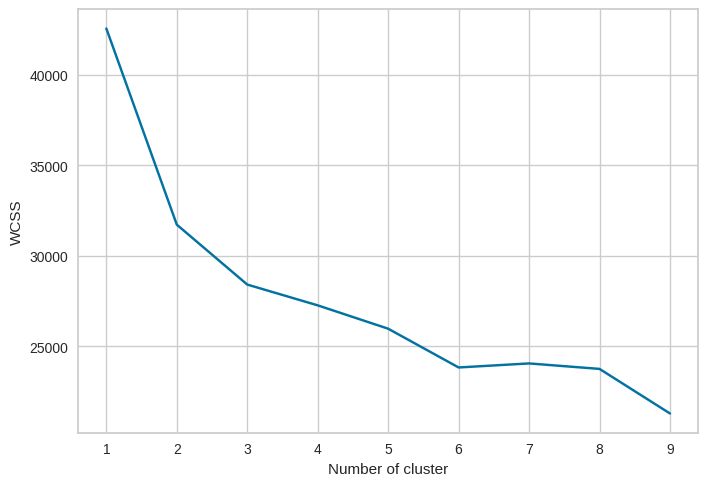

In [ ]:
# Initialize a dictionary to hold the inertia values
WCSS = {}

# Iterate through a range of Ks (can try 1 through 10) and fit the scaled data to the algorithm.
# Use inertia to get a value and store the inertia value for that particular k
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(df_scaled)
    WCSS[k] = kmeans.inertia_

# Create the elbow plot using the dictionary of values making it possible for us to choose the best value of k for k-means clustering on our dataset
plt.figure()
plt.plot(list(WCSS.keys()), list(WCSS.values()), 'bx-')
plt.xlabel("Number of cluster")
plt.ylabel("WCSS")
plt.show()

##### **Observations:**

Based on the above elbow plot, it looks like the most optimal value of k would be 2, but, the elbow could be a little ambiguous where we can't be sure what the best value of k would be to use.  Based on the graph, we can see that there are alot of dips in the curve.  To be sure we use the most optimal value of k we can use method number 2 to check the silhouette score at each k to give us a clearer picture.

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

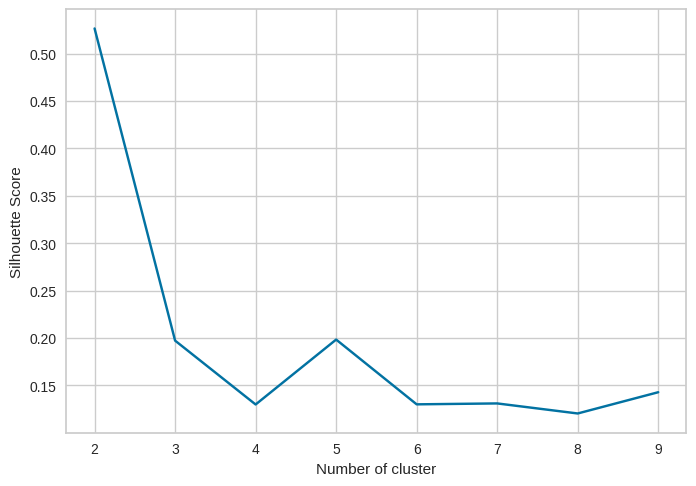

In [ ]:
#Create an empty dictionary to store the Silhouette score for each value of k
sc = {}

# Iterate through a range of Ks (can try 2 through 10) and fit the scaled data to the algorithm.
# Use silhouette score to get the value and store that value in the dictionary for that particular k.
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k).fit(df_scaled)
    labels = kmeans.predict(df_scaled)
    sc[k] = silhouette_score(df_scaled, labels)

#Elbow plot
plt.figure()
plt.plot(list(sc.keys()), list(sc.values()), 'bx-')
plt.xlabel("Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

##### **Observations:**
The maximum silhouette score gives us the most optimal number of clusters.  From the graph we can see that it is abundantly clear that the most optimal value of clusters for us to use in k-means would be at k = 2.  That would have been the same answer I got from the elbow plot but it never hurts to check the silhouette score to make sure you are choosing the "right" value of k.  Now we can continue on and perform our k-means clustering.

#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [ ]:
# This code runs our kmeans model with k=2 and then fits our previously scaled data to the model.
%%time
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(df_scaled)

CPU times: user 12 ms, sys: 1e+03 ns, total: 12 ms
Wall time: 11.7 ms


KMeans(n_clusters=2, random_state=1)

In [ ]:
#Adding cluster labels to the original data and scaled data
df_scaled_copy['Labels'] = kmeans.labels_
df['Labels'] = kmeans.labels_

In [ ]:
#Check to see if our labels are there
df.head(10)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Years_of_Loyalty,Labels
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,1,69,14,0
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,72,12,1
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,61,13,0
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,42,12,1
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,45,12,1
5,62513.0,0,1,16,520,42,98,0,42,14,2,6,4,10,6,0,0,59,13,0
6,55635.0,0,1,34,235,65,164,50,49,27,4,7,3,7,6,0,0,55,14,0
7,33454.0,1,0,32,76,10,56,3,1,23,2,4,0,4,8,0,0,41,13,1
8,30351.0,1,0,19,14,0,24,3,3,2,1,3,0,2,9,0,1,52,13,1
9,5648.0,1,1,68,28,0,6,1,1,13,1,1,0,0,20,0,0,76,12,1


##### **Observations:**
From the output of our kmeans cell we can see that our model took a total time of 11.7 milliseconds to run k-means as well as fit our scaled data to the model.  After running the model we add our cluster labels to both our scaled data and our original data.  Then we can take the head of our original data to see that we have a new column called labels with values of 0 or 1 representing which of our two clusters each row is present in.

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

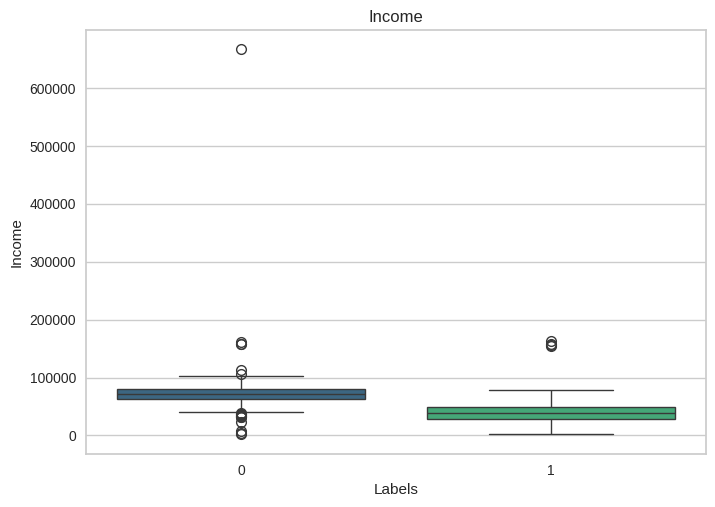

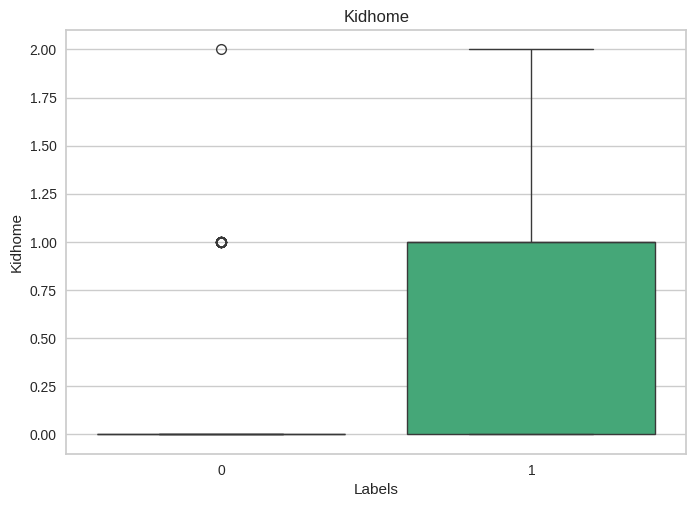

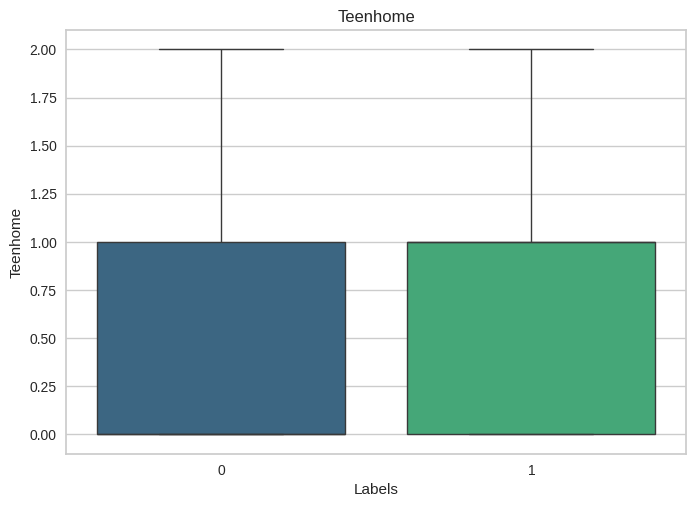

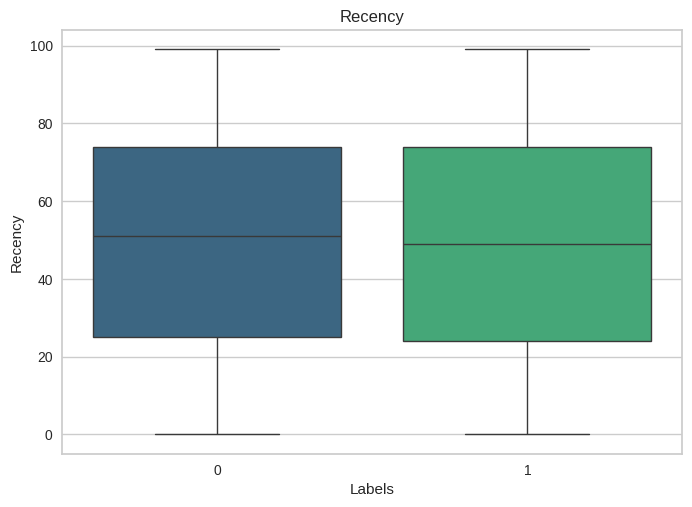

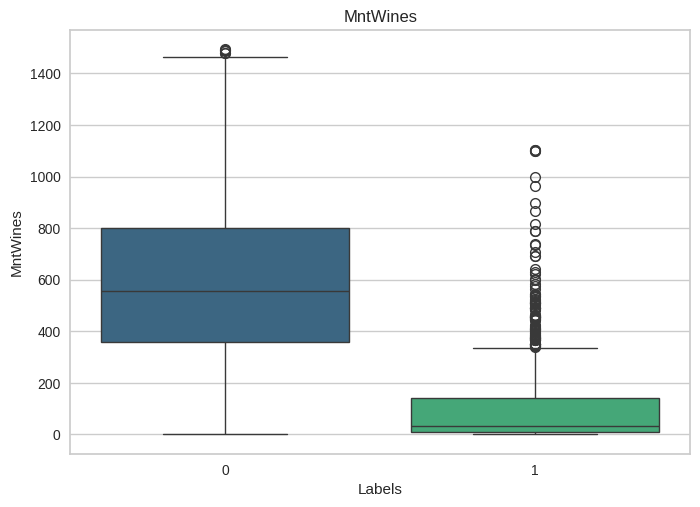

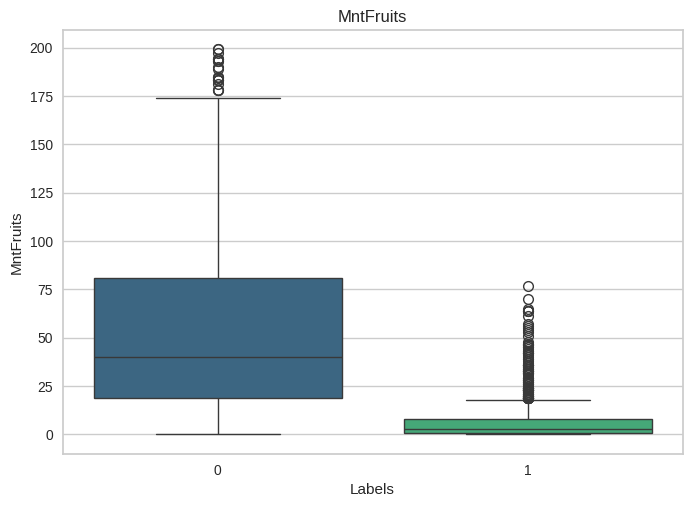

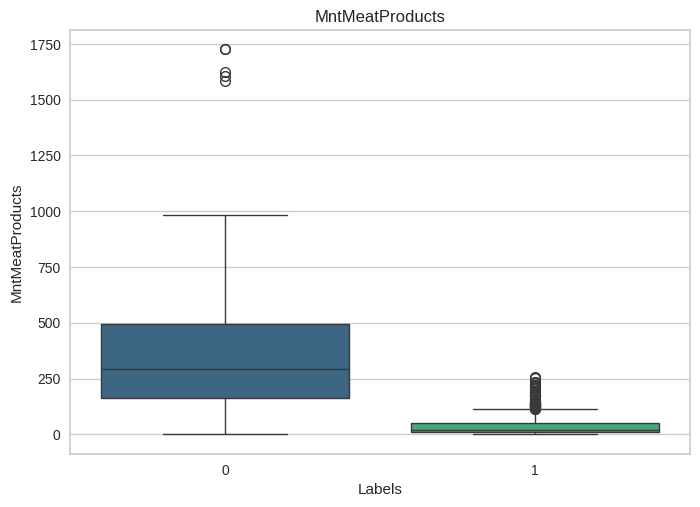

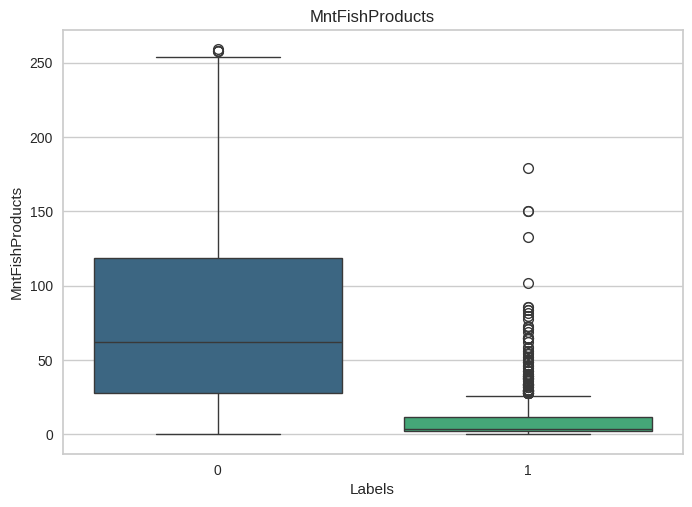

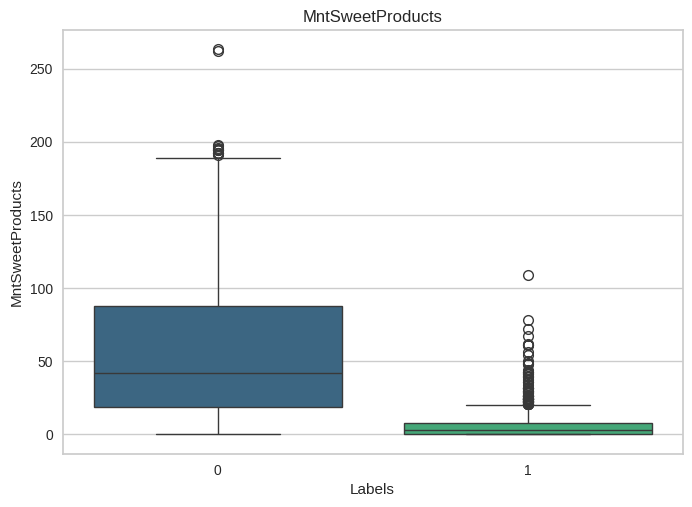

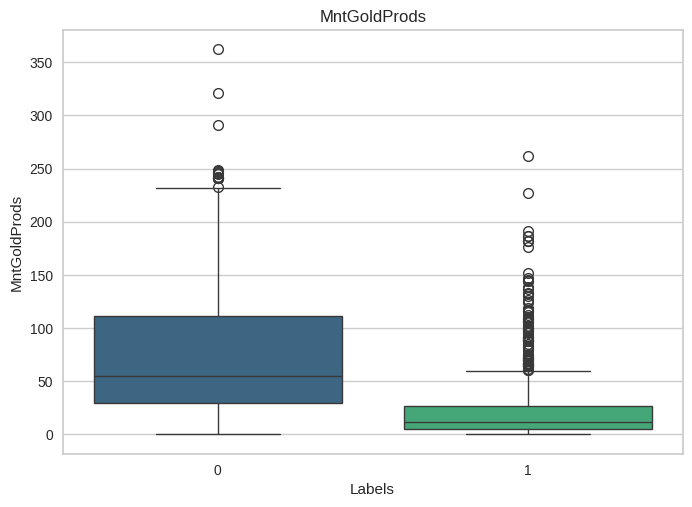

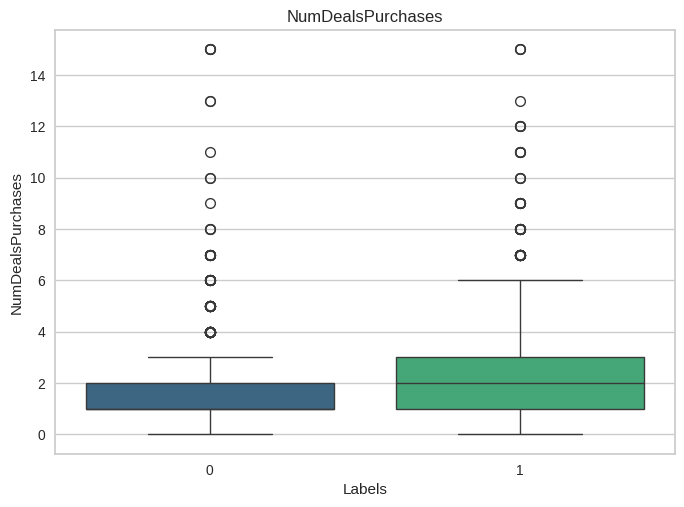

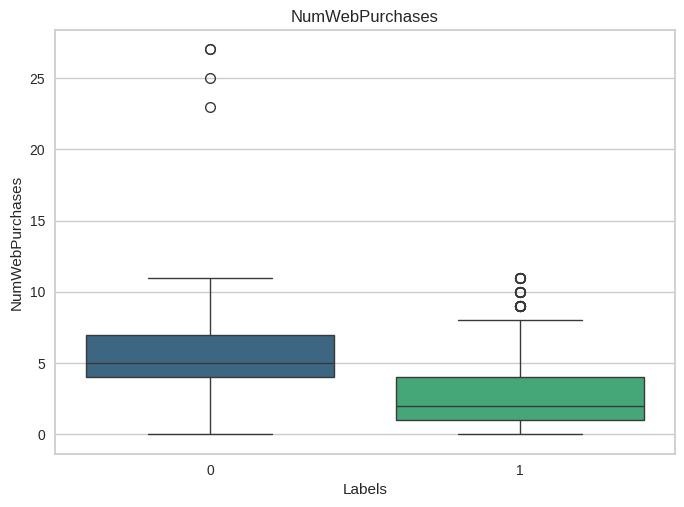

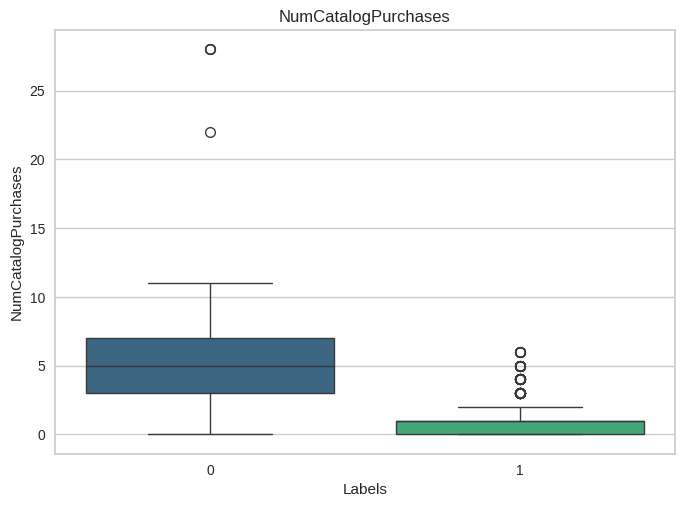

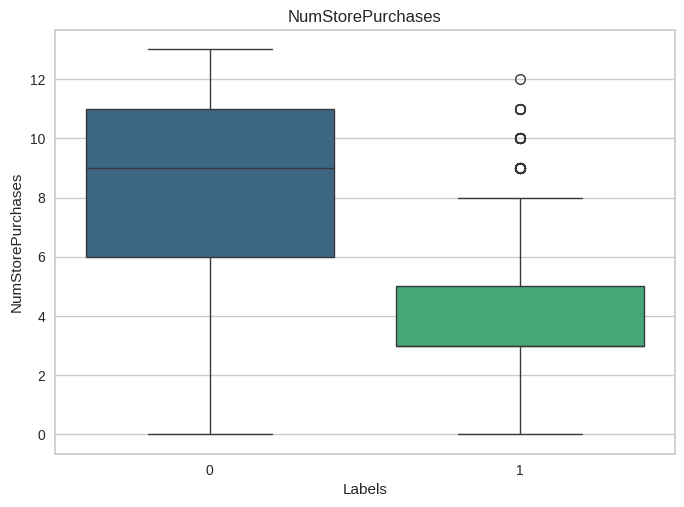

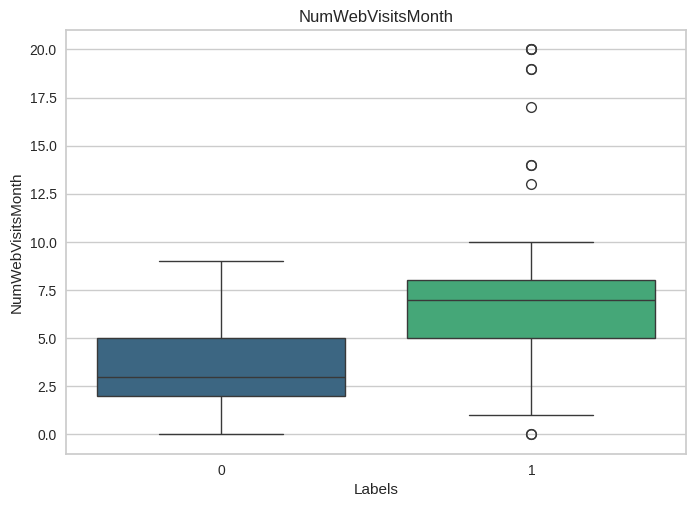

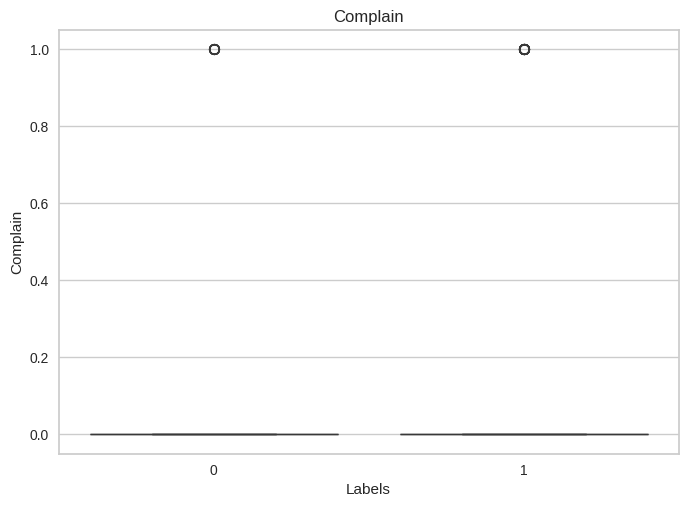

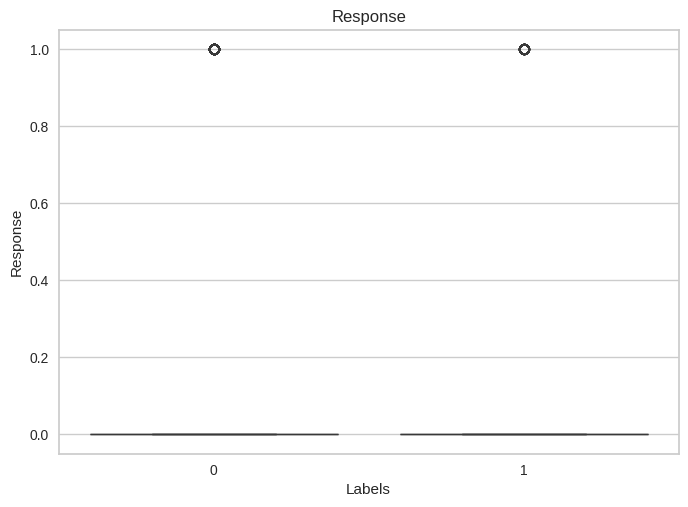

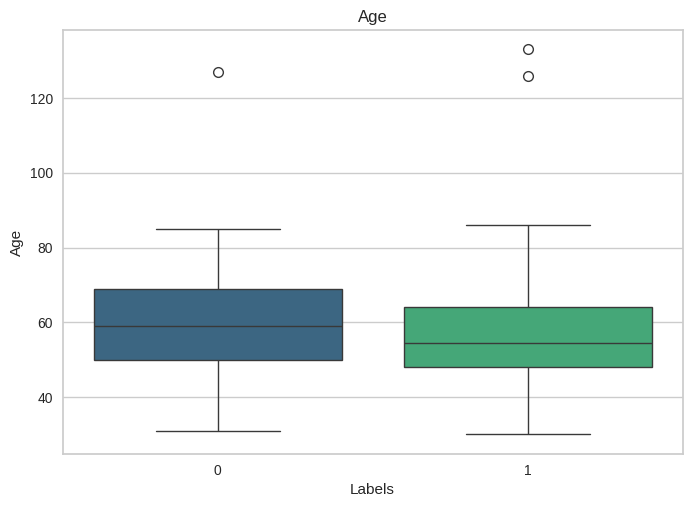

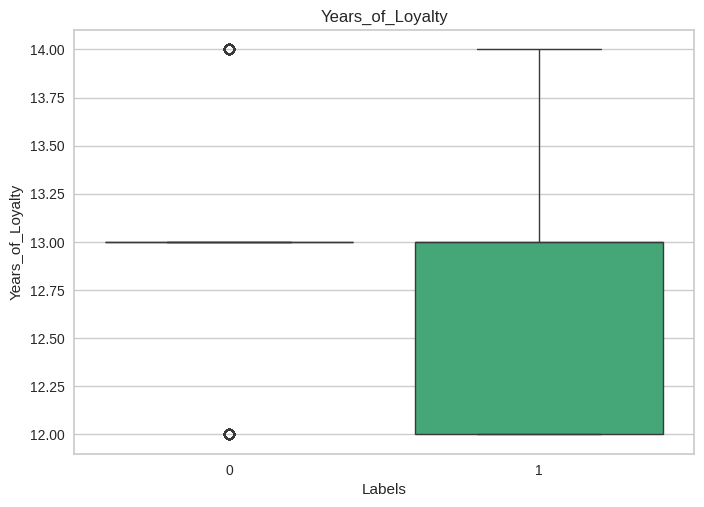

In [ ]:
# Creates a double boxplot for each column(minus Labels) where the x axis is labeled and separated based on cluster.
# We go back to the non-scaled data to make the graphs easier to interpret and extract insight from.
# Tried to use a few other methods but due to the sheer amount of columns in the dataset this was the easiest to view.
# For other methods the graphs were too small and did not get any better even when increasing the figsize().
# The scrolling up and down to look at different variables is a small price to pay in order to read the graphs and extract insights on the clusters.
for col in df_scaled_copy.columns[:-1]:
    sns.boxplot(x = 'Labels', y = col, data = df,palette='viridis')
    plt.title(col)
    plt.show()

##### **Observations:**

**Cluster Profiles:**

- Cluster 0 - Based on cluster differences we see Cluster 0 has more income, mostly no kids, more spent on wine, more spent on friuts, more spent on meat, more spent on fish, more spent on sweets, more spent on gold, Less purchases with discount, more web purchases, more catalog purchases, more store purchases, less web visits and older.  Therefore, I would profile Cluster 0 as those who are less cost concious due to their higher overall income.  Due to this they follow through with more purchases.  These individuals know what they want to buy it no matter the price.
- Cluster 1 - Cluster 1 has lower income, more young kids, less spent on wine, less spent on friuts, less spent on meat, less spent on fish, less spent on sweets, less spent on gold, more purchases with discount, less web purchases, less catalog purchases, less store purchases, more web visits and younger.  Therefore, I would profile Cluster 1 as those who are more cost concious due to their lower income and presence of young children.  These individuals buy the essentials, use more discount codes, have more web visits to compare prices before buying, and just purchase less in general in order to save money.

#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

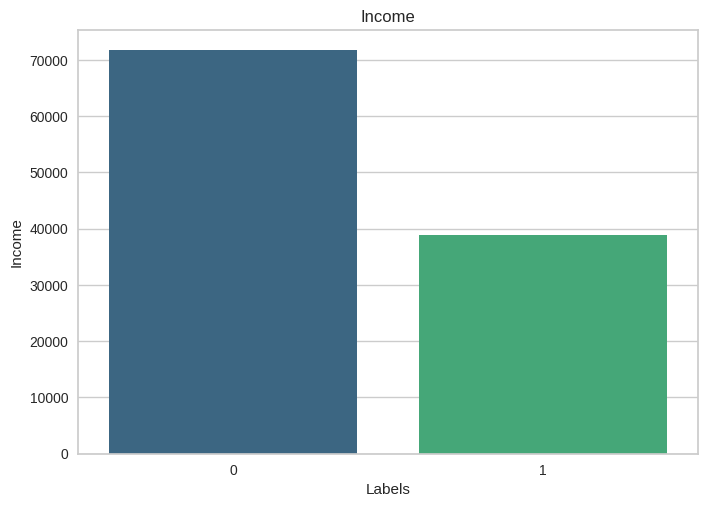

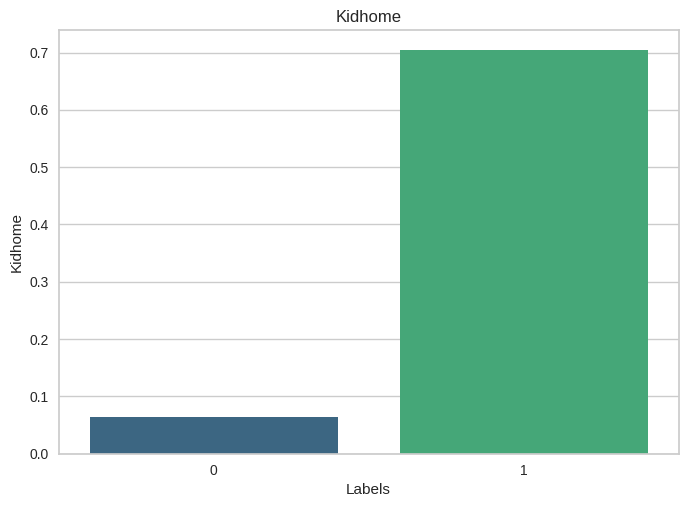

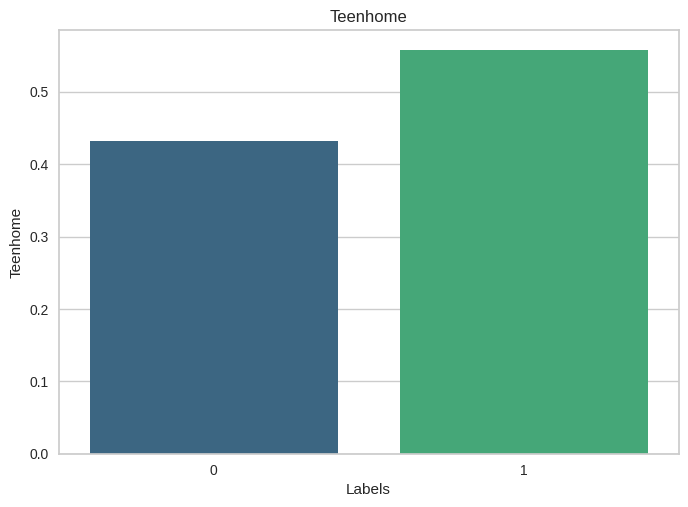

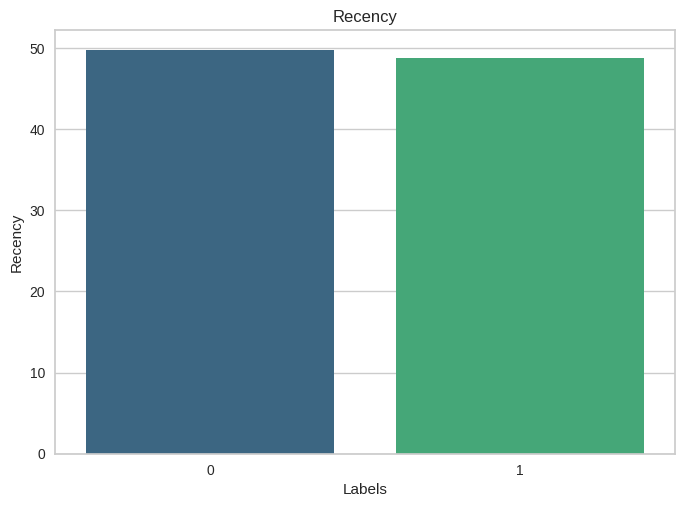

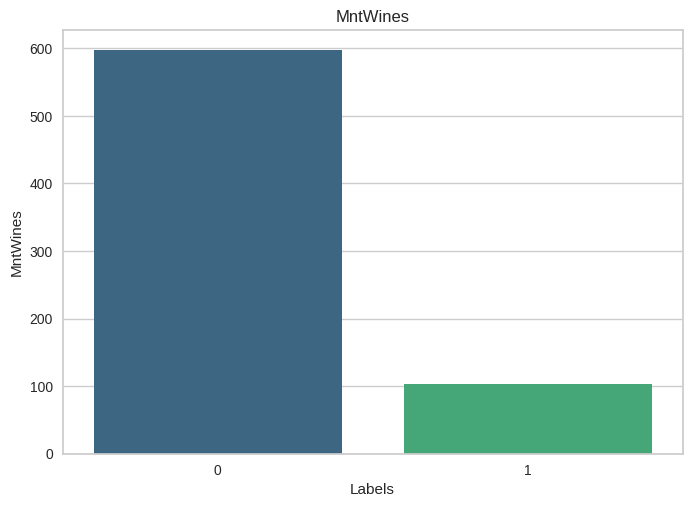

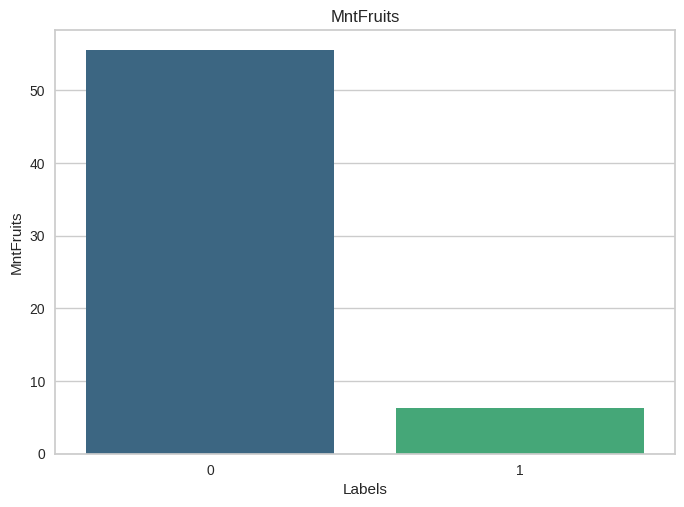

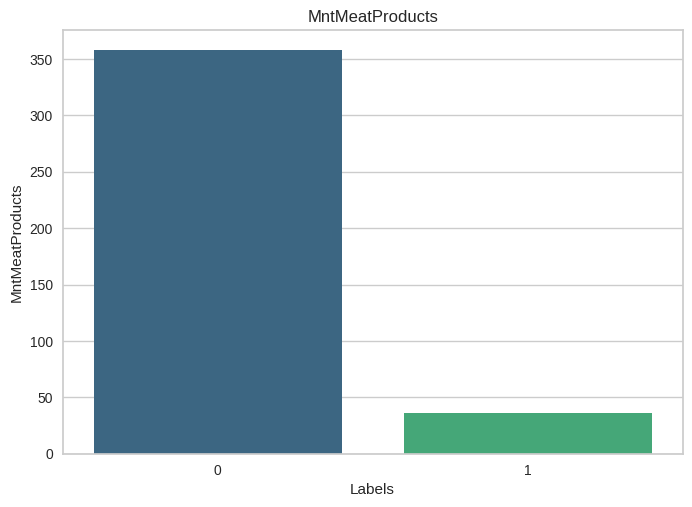

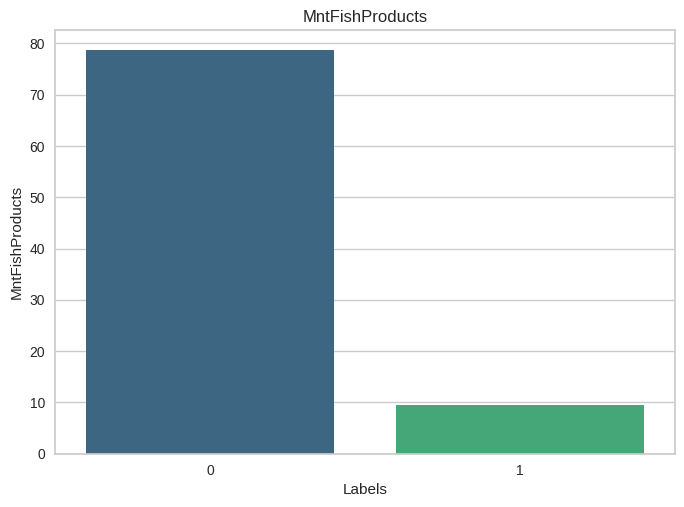

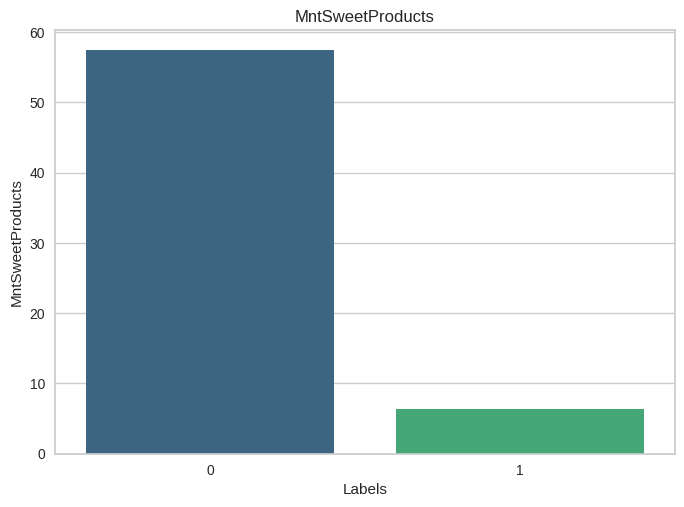

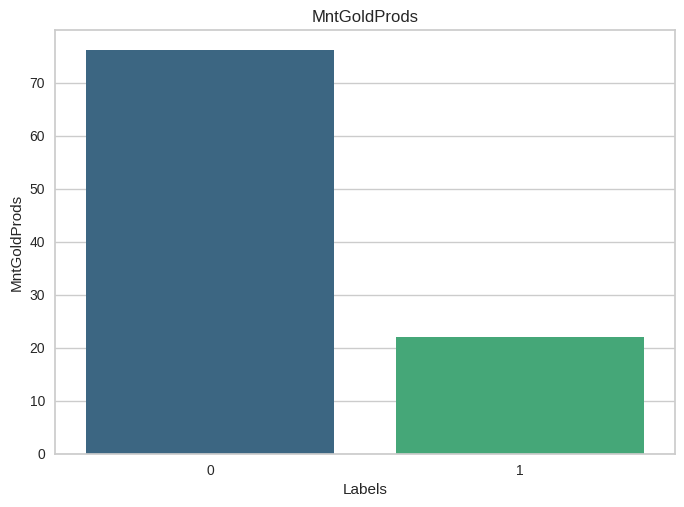

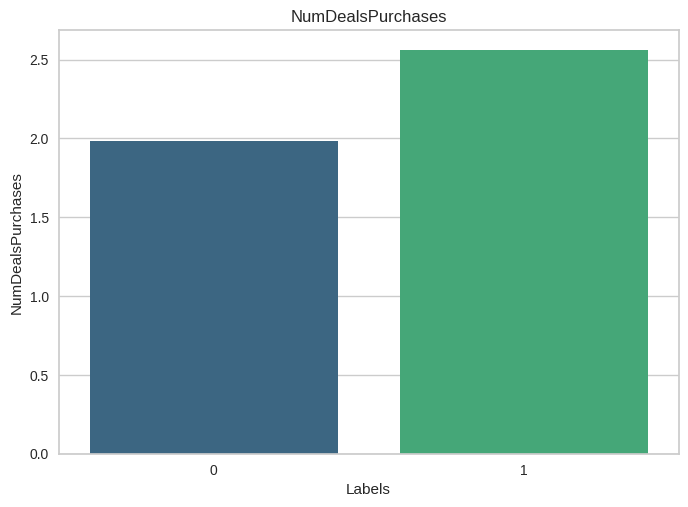

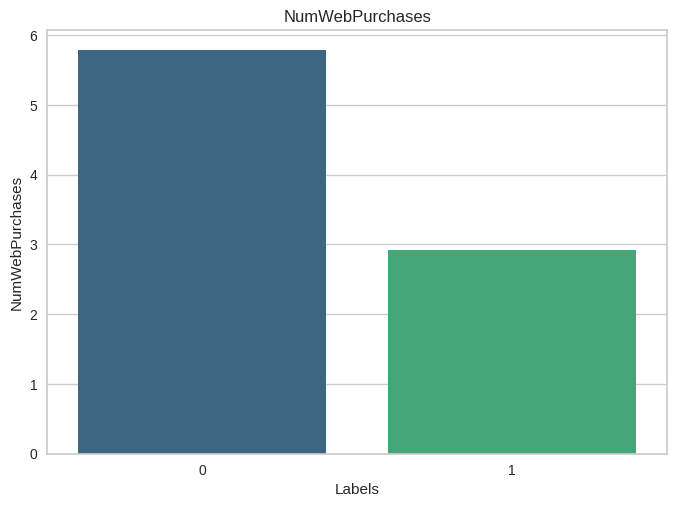

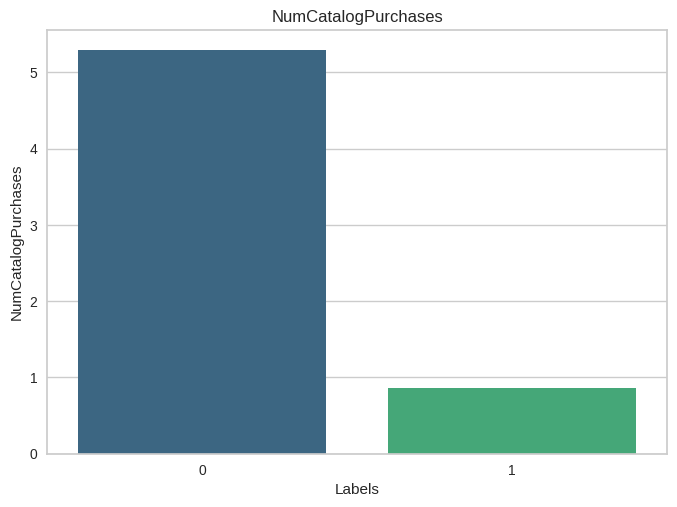

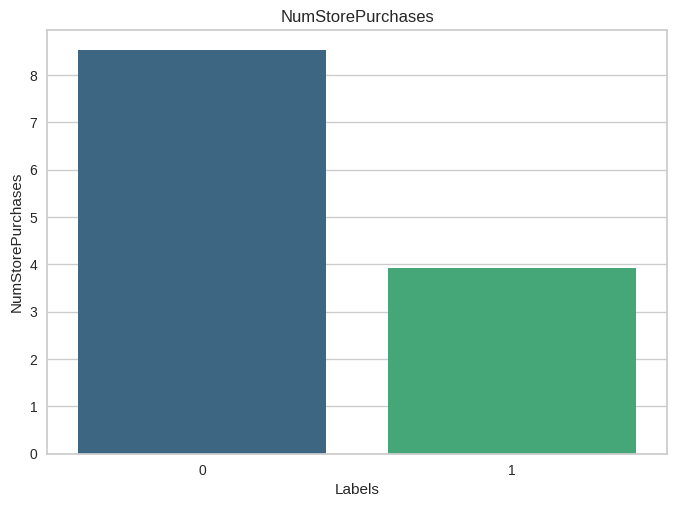

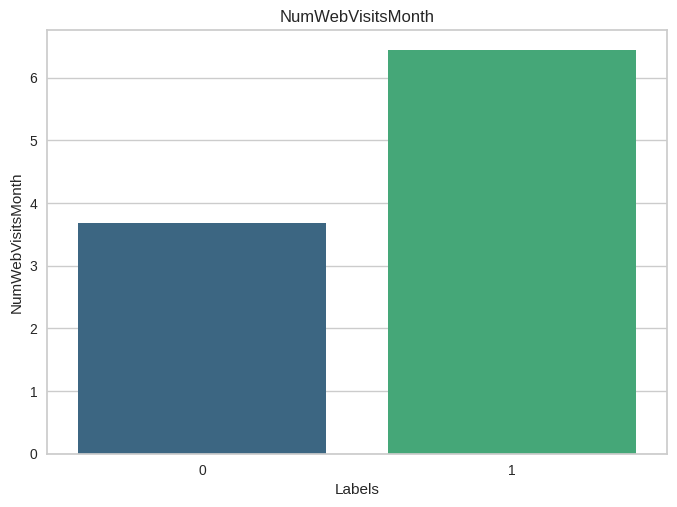

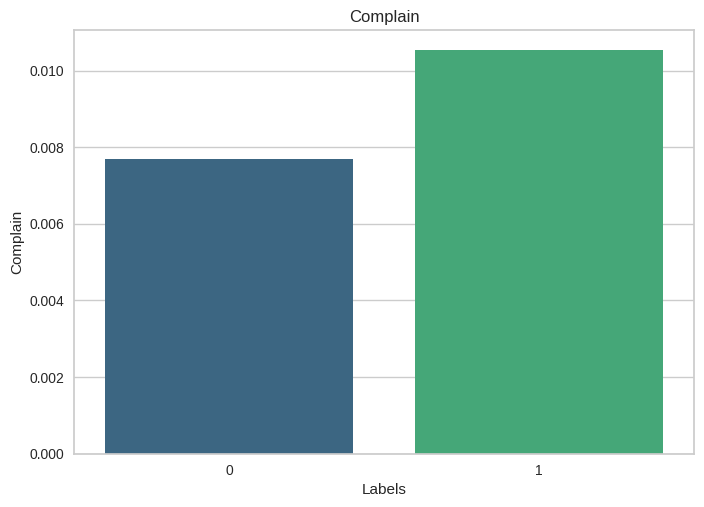

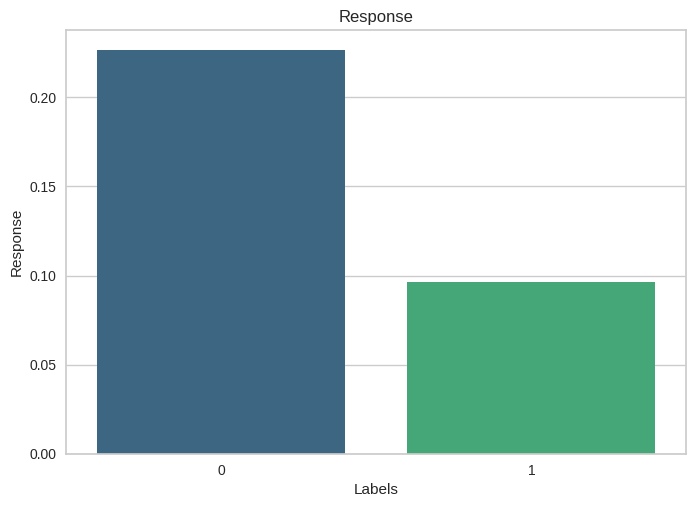

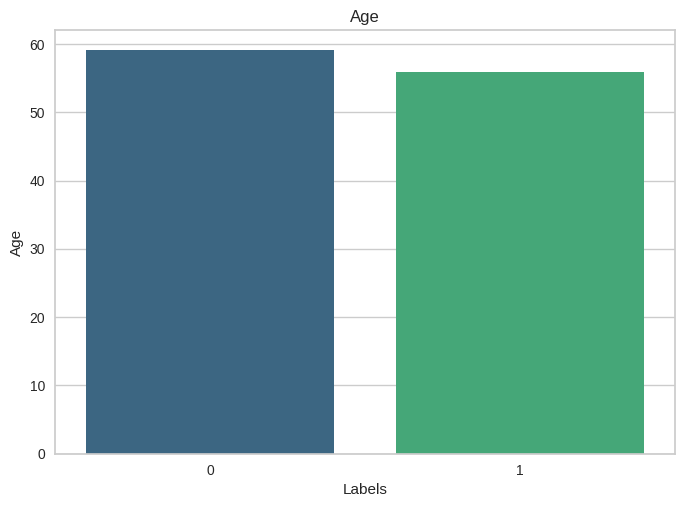

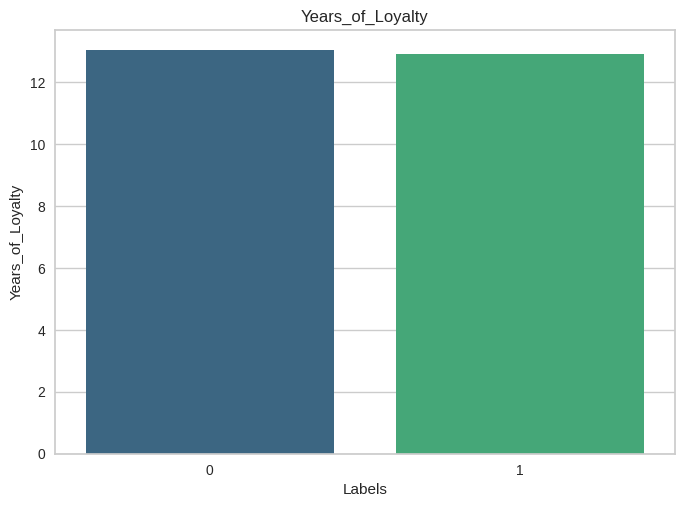

In [ ]:
# Creates a bar graph for each column(minus Labels) with one bar for each cluster
# Again, we go back to the non-scaled data to make the graphs easier to interpret and extract insight from.
# I also tried a few other methods for the bar graphs, but due to the sheer amount of columns in the dataset this was the easiest to view.
for col in df_scaled_copy.columns[:-1]:
    sns.barplot(x = 'Labels', y = col, data = df,palette='viridis',errorbar=None)
    plt.title(col)
    plt.show()

##### **Observations:**

**Cluster Profiles:**

- Cluster 0 - Based on cluster differences we see Cluster 0 has more income, mostly no young kids, more spent on wine, more spent on friuts, more spent on meat, more spent on fish, more spent on sweets, more spent on gold, Less purchases with discount, more web purchases, more catalog purchases, more store purchases, less web visits and older.  Therefore, I would profile Cluster 0 as those who are less cost concious due to their higher overall income as stated before.  We could take this one step further and say Cluster 0 is those who don't have children giving them extra expenses so they are able to spend more money rather than needing to save.
- Cluster 1 - Cluster 1 has lower income, more young kids, more teens, less spent on wine, less spent on friuts, less spent on meat, less spent on fish, less spent on sweets, less spent on gold, more purchases with discount, less web purchases, less catalog purchases, less store purchases, more web visits and younger.  Therefore, I would profile Cluster 1 as those who are more cost concious due to the presence of children.  These individuals buy the essentials, use more discount codes, have more web visits to compare prices before buying, and just purchase less in general in order to save money to support the family.

## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?



*   One thing we could do is rethink the marketing strategy by trying to increase sales in both groups.  We can start by sending out more targeted ads to Cluster 0 making it more likely that they will see something that they like/want and buy that item.  After that, we can lower the prices of essentials like milk, bread, eggs, etc. to be competitive or even a little lower priced than other stores.  By undergoing this small decrease in price, you can possibly increase your sales, and even get new customers over.  They will be paying less at your store for things they buy fairly often enough for them to save a bit of money over the course of the year.
*   Another thing we could do if permanently lowering prices is not in the cards is send out a survey to cluster 1 about their kids and ages to try and target limited time deals or ads toward the necessities for their children.  For example, if the family has young kids you could send them ads or discount codes for baby formula, diapers, wipes, etc.  If the children are a teenagers send them ads/discount codes for school supplies, clothes, cellphones, etc.  By doing this we can increase total sales as well as offer financial help to families with children by offering them essential goods at a reduced price.  Another beenefit to this is if they discounts come on a fairly regular basis customers will develop loyalty and want to keep shopping at your store for years to come.

